**Problem 3**: Suppose we have a 1-DOF arm. We want to control both the position and velocity of the arm as it carries out a motion. How to ensure that the motion remains smooth, the torque is consistent, and the position is precise?

PID itself is a **feedback controller**. It reacts to errors in the system. Looking closely into the time series graphs in the previous section, we can see that as the target changes and the motion is carried out, the error jumps massively and the controller overcorrects before damping down again. To control velocity, we'll need something else.

A way to eliminate that is to add a **feedforward** term. We tell the system that we need only this much energy to go somewhere, and the feedforward term carries us $90\%$ of the way. Then, the PID only has to correct small, local errors. For our system, let's try to make feedforward hold the position first. Then, the term is simply:
$$
\tau = mg\dfrac{l}{2} \cos \theta
$$
We will also be modelling some disturbances too. The PID controller alone would take more time and have more error locally around these small pushes. With the feedfoward term and some aggressive $K_d$, we can handle them pretty well:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from control import PID, HalfSineDisturbance

dt = 0.01 # Time step
time = 20.0 # Total simulation time
t = np.arange(0, time, dt)

# System state
theta = np.zeros_like(t)
omega = np.zeros_like(t)
u = np.zeros_like(t)      # control input
load = np.zeros_like(t) # disturbance torque
accel = np.zeros_like(t) # angular acceleration

theta[0] = np.pi / 2 
omega[0] = 0.0
accel[0] = 0.0

# Dynamics
b = 0.1  # Damping coefficient
m = 2.0  # Mass of the arm
length = 0.5  # Length of the arm
g = 9.81  # Acceleration due to gravity
inertia = (1/3) * m * length**2  # Moment of inertia of the arm

controller = PID(Kp=6.0, Ki=0.0, Kd=5.0, alpha=0.9, u_max=40.0, u_min=-40.0, setpoint=0.0)
disturbance = HalfSineDisturbance(shot_rate=0.5, shot_duration=0.4, shot_torque=5.0, bidirectional=True)

# Simulation
for k in range(len(t)-1):
    load[k] = disturbance.update(dt)
    u[k] = controller.control(current_value=theta[k], current_velocity=omega[k], dt=dt) + m * g * (length/2) * np.cos(controller.setpoint)

    ambient_disturbance = np.random.normal(0, 0.1)

    # Angular acceleration
    theta_ddot = (u[k] - b * omega[k] - m * g * (length/2) * np.cos(theta[k]) + ambient_disturbance + load[k]) / inertia

    # Euler integration
    omega[k+1] = omega[k] + theta_ddot * dt
    theta[k+1] = theta[k] + omega[k+1] * dt
    accel[k+1] = theta_ddot

u[-1] = u[-2] # Last control input value for plotting

# Plotting

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(18, 14), sharex=True)

ax1.plot(t, theta)
ax1.axhline(controller.setpoint, color='r', linestyle='--')
ax1.set_ylabel("Angular Position (rad)")
ax1.set_xlabel("Time (s)")

ax2.step(t, u, where='post')
ax2.set_ylabel("Control Input (N·m)")
ax2.set_xlabel("Time (s)")

ax3.step(t, load, where='post')
ax3.set_ylabel("Disturbance Torque (N·m)")
ax3.set_xlabel("Time (s)")

ax4.plot(t, omega)
ax4.set_ylabel("Angular Velocity (rad/s)")
ax4.set_xlabel("Time (s)")

ax5.plot(t, accel)
ax5.set_ylabel("Angular Acceleration (rad/s²)")
ax5.set_xlabel("Time (s)")

plt.show()

We modeled the disturbance as a half sine pulse with the equation: 
$$
\tau_d = A\sin(\pi \dfrac{t}{T})
$$
And as predicted, the model works very well near the operating point. Even with quite strong disturbances and zero anticipation, the error is still very small after every push. Also notice how a PD only controller also works. In the previous example, the integral term had to accumulate enough error to know how much torque we need at steady state. Because this is a simulation and our parameters are perfect, the feedforward term completely replaces the need for the integral term. In a real problem though, people tend to have a very small $K_i$ to help out with imperfections in instrumentation.

Now let's go a step further. We could see that, near the start, our actuator saturated and it provided very large torque. Plotting the velocity and the acceleration, we can see that it was a very fast and violent motion: The controller exhibits high transient acceleration due to commanding a step change in position. This produces large inertial forces on the arm, gearbox, bearings, and joints, wearing them down faster over time. Also, since $\tau \propto i$, this makes heating become a problem too. Worse, if the arm is holding something, it may cause slippage or slosh. 

This is where feedforward become even more useful. The entire system dynamics give us the formula. For any system, if we can determine their dynamics ODE, we can use that exact equation to implement feedforward. This is the foundation of **model-based control**. For this problem, we can determine the feedforward term as:
$$
u_{ff} = I \ddot{\theta} + b \dot{\theta} + mg\dfrac{l}{2}\cos \theta
$$
Now, we need to bound the terms $\ddot{\theta}$ and $\dot{\theta}$. To ensure the motion is smooth, we could try limiting the acceleration. Knowing $\alpha_{max}$, $\omega_{max}$ and the total distance $D$ of the motion, we can plan the motion beforehand using a **trapezoidal profile**. Simply, it divides the motion into three phases:

1. Constant acceleration until it reaches $v_{max}$
2. Cruise at $v_{max}$
3. Constant deceleration until it reaches $v = 0$

In code, we have to return a slice of the profile at any point in time. So, suppose our parameters are given, our equations in each phase of the motion are as follows. First, we check if the motion ever reaches $v_max$. We know:
$$
t_{accel} = \dfrac{v_{max}}{a_{max}} \Rightarrow d_{accel} = \dfrac{1}{2}a_{max} t_{accel}^2
$$
So, if $2 d_{accel} > D$, it only generates a triangle. Call this case $2$ and the full trapezoid case $1$.

**Case 1:**

*Phase 1*
$$
\begin{cases}
\theta (t) = & \dfrac{1}{2}a_{max} t^2  \\
\omega (t) = & a_{max} t\\
\alpha (t) = & a_{max} 
\end{cases}
$$
Compute once $d_1 =  \dfrac{1}{2}a_{max} t_{accel}^2$

*Phase 2*
$$
\begin{cases}
\theta (t) = & d_1 + v_{max}(t - t_{accel})  \\
\omega (t) = & v_{max}\\
\alpha (t) = & 0 
\end{cases}
$$
Compute once $d_2 = D - 2 d_{accel}$ and $t_2 = \dfrac{d_2}{v_{max}}$

*Phase 3*
$$
\begin{cases}
\theta (t) = & d_2 - \dfrac{1}{2}a_{max} (t-t_{accel} - t_2)^2  \\
\omega (t) = & -a_{max} (t-t_{accel} - t_2)\\
\alpha (t) = & -a_{max} 
\end{cases}
$$

**Case 2**

Compute once $t_{accel} = \sqrt{d a_{max}}$

*Phase 1*
$$
\begin{cases}
\theta (t) = & \dfrac{1}{2}a_{max} t^2  \\
\omega (t) = & a_{max} t\\
\alpha (t) = & a_{max} 
\end{cases}
$$

Compute once $d_1 =  \dfrac{1}{2}a_{max} t_{accel}^2$

*Phase 2*
$$
\begin{cases}
\theta (t) = & d_1 - \dfrac{1}{2}a_{max} (t-t_{accel})^2  \\
\omega (t) = & - a_{max} (t-t_{accel})\\
\alpha (t) = & a_{max} 
\end{cases}
$$

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from control import TrapezoidalProfile
        
profile = TrapezoidalProfile(start_pos=np.pi/4, end_pos=0, max_vel=np.pi, max_accel=(np.pi)**2)

t = np.linspace(0, profile.total_time, 1000)
x = np.array([profile.position(dt) for dt in t])
v = np.array([profile.velocity(dt) for dt in t])
a = np.array([profile.acceleration(dt) for dt in t])
y = np.zeros_like(x)  # y is always zero for a 1D motion

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

ax1.plot(t, x, label='Position (rad)')
ax1.set_ylabel("Angular Position")

ax2.plot(t, v, label='Velocity (rad/s)')
ax2.axhline(0, color='r', linestyle='--')
ax2.set_ylabel("Velocity (rad/s)")

ax3.plot(t, a, label='Acceleration (rad/s²)')
ax3.axhline(0, color='r', linestyle='--')
ax3.set_ylabel("Acceleration (rad/s²)")
ax3.set_xlabel("Time")

plt.tight_layout()
plt.show()

We can clearly see that the position is much smoother. Now, we can feed the inputs into the arm's feedforward equation:

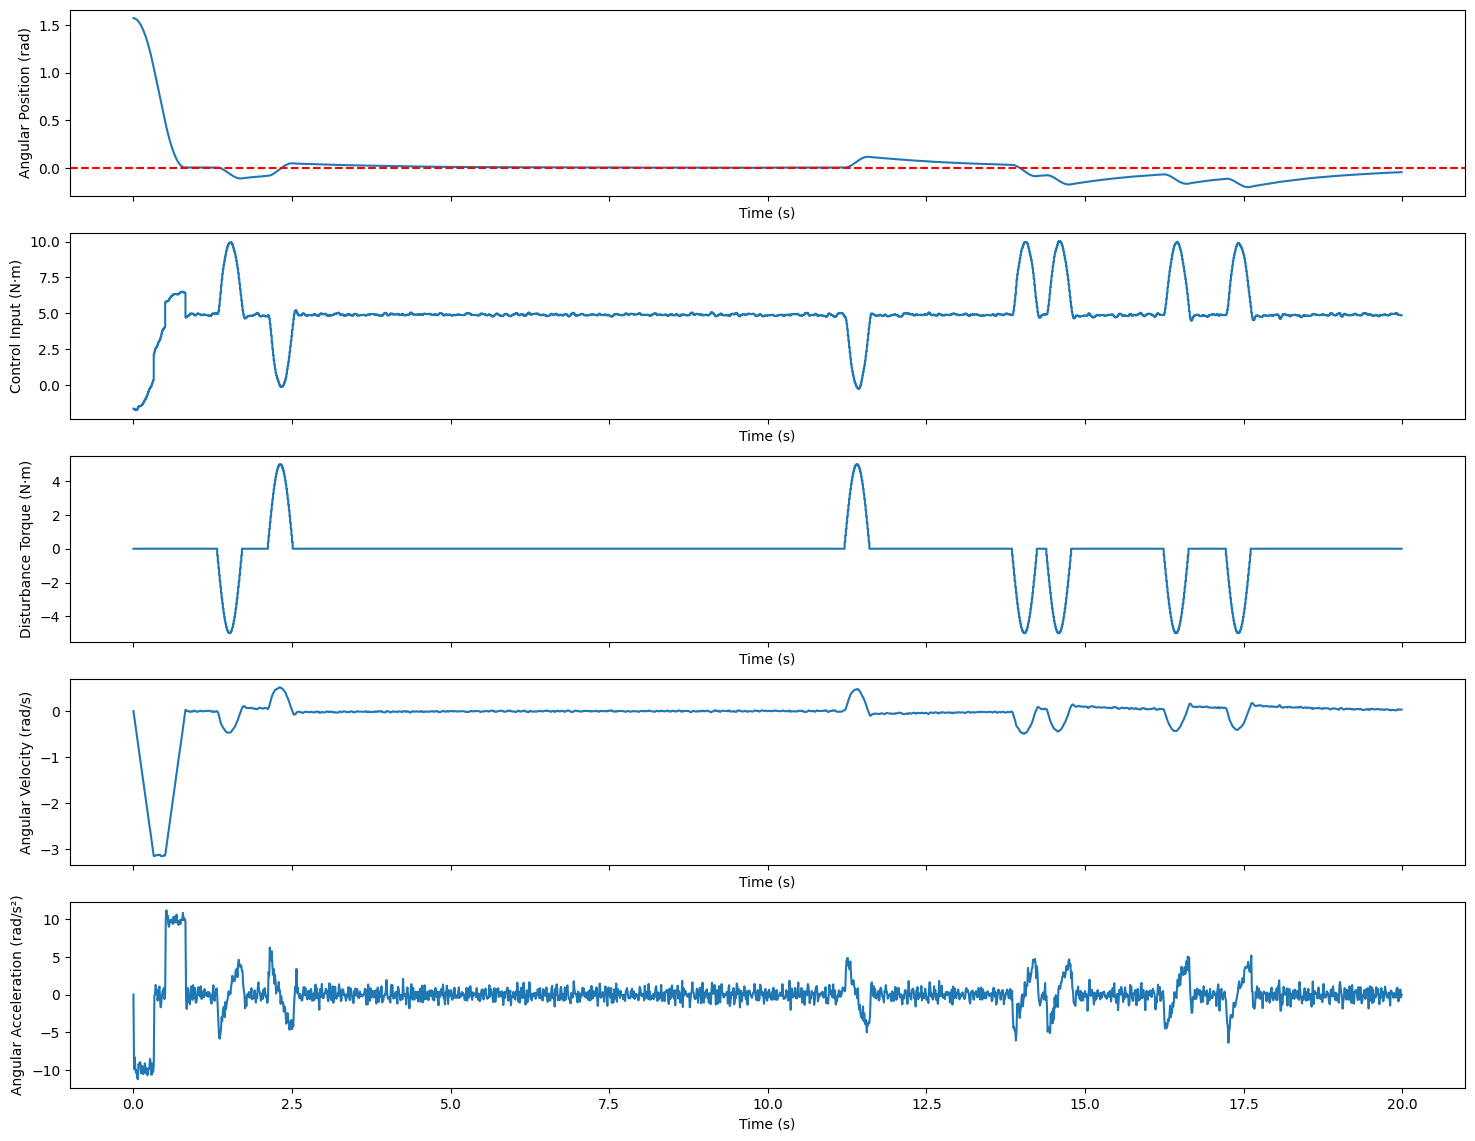

In [33]:
import matplotlib.pyplot as plt
import numpy as np

from control import PID, HalfSineDisturbance, TrapezoidalProfile

dt = 0.01 # Time step
time = 20.0 # Total simulation time
t = np.arange(0, time, dt)

# System state
theta = np.zeros_like(t)
omega = np.zeros_like(t)

load = np.zeros_like(t) # disturbance torque
accel = np.zeros_like(t) # angular acceleration

u = np.zeros_like(t)      # control input
pid = np.zeros_like(t)      # PID control input
ff = np.zeros_like(t)      # Feedforward control input

theta[0] = np.pi / 2 
omega[0] = 0.0
accel[0] = 0.0

# Desired position
target = 0

# Dynamics
b = 0.1  # Damping coefficient
m = 2.0  # Mass of the arm
length = 0.5  # Length of the arm
g = 9.81  # Acceleration due to gravity
inertia = (1/3) * m * length**2  # Moment of inertia of the arm

profile = TrapezoidalProfile(start_pos=theta[0], end_pos=target, max_vel=np.pi, max_accel=(np.pi)**2)

controller = PID(Kp=6.0, Ki=0.0, Kd=10.0, alpha=0.6, u_max=40.0, u_min=-40.0, setpoint=target)

disturbance = HalfSineDisturbance(shot_rate=0.5, shot_duration=0.4, shot_torque=5.0, bidirectional=True)

# Simulation
for k in range(len(t)-1):
    # Feedforward term based on the trapezoidal profile

    t_now = t[k]

    theta_ref = profile.position(t_now)
    omega_ref = profile.velocity(t_now)
    alpha_ref = profile.acceleration(t_now)

    pos_error = theta_ref - theta[k]
    vel_error = omega_ref - omega[k]

    load[k] = disturbance.update(dt)
    ambient_disturbance = np.random.normal(0, 0.1)

    pid[k] = controller.control(current_value=theta[k], current_velocity=omega[k], dt=dt, setpoint=theta_ref, setpoint_velocity=omega_ref) 
    ff[k] = m * g * (length/2) * np.cos(theta_ref) + b * omega_ref + inertia * alpha_ref  # Feedforward term

    u[k] = pid[k] + ff[k]  # Total control input


    # Angular acceleration
    theta_ddot = (u[k] - b * omega[k] - m * g * (length/2) * np.cos(theta[k]) + ambient_disturbance + load[k]) / inertia

    # Euler integration
    omega[k+1] = omega[k] + theta_ddot * dt
    theta[k+1] = theta[k] + omega[k+1] * dt
    accel[k+1] = theta_ddot

u[-1] = u[-2] # Last control input value for plotting

# Plotting

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(18, 14), sharex=True)

ax1.plot(t, theta)
ax1.axhline(target, color='r', linestyle='--')
ax1.set_ylabel("Angular Position (rad)")
ax1.set_xlabel("Time (s)")

ax2.step(t, u, where='post')
ax2.set_ylabel("Control Input (N·m)")
ax2.set_xlabel("Time (s)")

ax3.step(t, load, where='post')
ax3.set_ylabel("Disturbance Torque (N·m)")
ax3.set_xlabel("Time (s)")

ax4.plot(t, omega)
ax4.set_ylabel("Angular Velocity (rad/s)")
ax4.set_xlabel("Time (s)")

ax5.plot(t, accel)
ax5.set_ylabel("Angular Acceleration (rad/s²)")
ax5.set_xlabel("Time (s)")

plt.show()